<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Learning Goals


**In this tutorial, you will see an example of building, compiling, and training a CNN on simulated astronomical data.**  By the end of this tutorial you will have a working example of a simple Convolutional Neural Network (CNN) in Keras.  This CNN can be adapted for any machine learning task that inputs an image and learns a continuous-valued label (regression). 

## Introduction
Convolutional Neural Networks (CNNs) are a class of machine learning (ML) algorithms that can extract information from images.  In this notebook, you will walk through the basic steps of applying a CNN to data:
1. Load the data and visualize a sample of the data
2. Divide the data into training, validation, and testing sets.
3. Build a CNN in Keras
4. Compile the CNN
5. Train the CNN to perform a regression task
6. Evaluate the results.

CNNs can be applied to a wide range of image recognition tasks, and while they are often used for image classification, this notebook builds a CNN for an image regression task.  Here, we will build, compile, and train CNN to estimate galaxy cluster log(masses) from simulated single-band (or _monochromatic_) X-ray images of galaxy clusters.


## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [22]:
%matplotlib widget
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import keras
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D
from keras.layers import GlobalAveragePooling2D


## Cluster Mass Regression

This notebook trains a CNN to estimate cluster mass from X-ray images. The key evaluation unit is the cluster, not an individual image, because each cluster has up to three lines of sight.

### 1. Load the data

The FITS file contains the X-ray images and metadata, including `cluster_id`, `view_los`, `log_M500`, and the original train/validation/test flags.

In [2]:
filename = r'/Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_TNG_data.fits'
hdul = fits.open(filename)
image_size = hdul[1].data.shape[1]

### 2. Prepare the baseline split

The original split is retained for the baseline model. The cross-validation model below uses cluster-level folds instead, preventing different views of one cluster from appearing in both training and validation data.

In [3]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [4]:
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [18]:
input_shape = (image_size, image_size, 1)
model = Sequential([
    Input(shape=input_shape),
    Conv2D(16, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    GlobalAveragePooling2D(),
    Dropout(0.1),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(100, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear')
])

### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [6]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [7]:
epochs = 5
batch_size = 16 #lower this value if you get a memory error
hist = model.fit(train_X, train_Y, batch_size=batch_size, verbose=True,  epochs=epochs)

Epoch 1/5
 1/50 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - loss: 0.1386

error: operand #1 does not dominate this use
E0000 00:00:1787803087.980086  167353 meta_optimizer.cc:967] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
W0000 00:00:1787803087.980277  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
error: operand #0 does not dominate this use
W0000 00:00:1787803088.116907  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5485
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1293
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4071
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0570


### 6. Evaluate the results

Next, we will plot up the true and predicted log(masses).  We have only trained for 5 epochs, so we expect noisy results and catastrophic outliers.  Don't panic -- we will discuss how to fix this in the FAQs. 

error: operand #1 does not dominate this use
W0000 00:00:1787803093.034511  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
error: operand #1 does not dominate this use
W0000 00:00:1787803093.079272  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 


Text(0.5, 1.0, 'Results after 5 epochs')

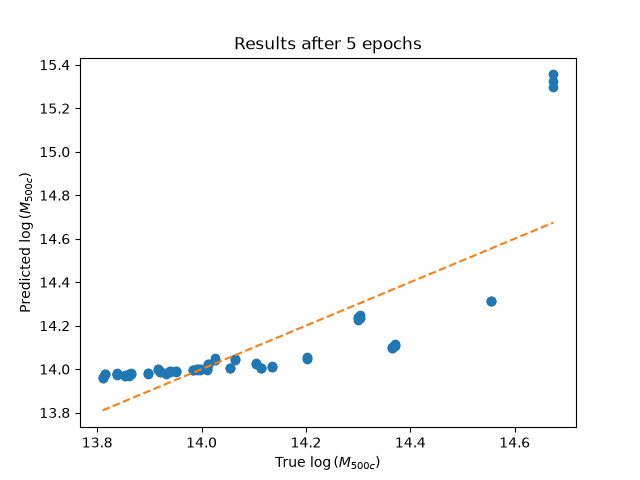

In [8]:
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()
# Remember when we subtracted off the min in an earlier cell?  In the next line, we're putting it back in!
plt.scatter(test_Y + norm, prediction + norm, c='C0', label='model predictions')
x = np.linspace(np.min(test_Y+norm), np.max(test_Y+norm), 100)
plt.plot(x,x,ls='--', c='C1', label='one-to-one line')
plt.xlabel('True '+r'$\log\left(M_{500c}\right)$')
plt.ylabel('Predicted '+r'$\log\left(M_{500c}\right)$')
plt.title('Results after {:.0f} epochs'.format(epochs))


## Dataset audit and cross-validation

The following cells convert the FITS metadata to a DataFrame, check cluster completeness, and run cluster-aware cross-validation.

In [12]:
data = {}

table = hdul[2].data

for name in table.names:
    arr = np.array(table[name])

    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.astype(arr.dtype.newbyteorder('='))

    data[name] = arr

df = pd.DataFrame(data)

### 3. Check cluster completeness

Each complete cluster should contain exactly the three lines of sight: `x`, `y`, and `z`. Incomplete clusters are excluded from cross-validation.

In [13]:
# Verify that every cluster has exactly the three expected lines of sight.
los_by_cluster = df.groupby('cluster_id')['view_los'].agg(lambda values: set(values))
expected_los = set(df['view_los'].dropna().unique())
complete_clusters = los_by_cluster[los_by_cluster == expected_los].index.to_numpy()
incomplete_clusters = los_by_cluster[los_by_cluster != expected_los]

print(f'Expected lines of sight: {sorted(expected_los)}')
print(f'Complete clusters: {len(complete_clusters)} out of {len(los_by_cluster)}')
print('Incomplete or duplicated clusters:')
print(incomplete_clusters)

assert all(len(df[df['cluster_id'] == cid]) == len(expected_los) for cid in complete_clusters), \
    'At least one cluster has duplicate rows for a line of sight.'

Expected lines of sight: ['x', 'y', 'z']
Complete clusters: 328 out of 329
Incomplete or duplicated clusters:
cluster_id
0    {y, z}
Name: view_los, dtype: object


In [19]:
images = hdul[1].data

### 6. Cluster-aware 10-fold cross-validation

The CV loop splits complete `cluster_id` groups, so all three lines of sight remain in the same fold. Cluster 0 is excluded because it is incomplete. Set `epochs` and uncomment `cv_rot` when the rotation-augmented comparison is needed.

In [42]:
n_folds = 10
epochs = 50
batch_size = 32

# `clusters` contains one entry per cluster, not one entry per image.
# Therefore KFold assigns complete cluster IDs to folds.
clusters = np.sort(complete_clusters)
assert len(clusters) >= n_folds

# Store every image row belonging to each cluster. These indices are expanded
# only after the cluster-level fold assignment has been made.
cluster_indices = {
    cid: df.index[df['cluster_id'] == cid].to_numpy()
    for cid in clusters
}
cluster_masses = {
    cid: df.loc[df['cluster_id'] == cid, 'log_M500'].iloc[0]
    for cid in clusters
}
norm_cv = np.nanmin(list(cluster_masses.values()))
cluster_masses = {cid: mass - norm_cv for cid, mass in cluster_masses.items()}

In [43]:
def build_model(with_rotation=False, input_shape=(*images.shape[1:], 1)):
    model_layers = [Input(shape=input_shape)]
    if with_rotation:
        model_layers.extend([
            keras.layers.RandomRotation(0.25),
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomFlip('vertical')
        ])
    model_layers.extend([
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        GlobalAveragePooling2D(),
        Dropout(0.1),
        Dense(200, activation='relu'),
        Dropout(0.1),
        Dense(100, activation='relu'),
        Dense(20, activation='relu'),
        Dense(1, activation='linear')
    ])
    model = Sequential(model_layers)
    model.compile(loss='mean_squared_error',
                  optimizer=keras.optimizers.Adam(learning_rate=0.0002),
                  run_eagerly=True,
                  jit_compile=False)
    return model

In [44]:
def run_cv(with_rotation=False):
    folds = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    fold_histories = []

    for fold, (train_ids, val_ids) in enumerate(folds.split(clusters), start=1):
        # KFold splits unique cluster IDs, so no cluster can be in both sets.
        train_clusters = clusters[train_ids]
        val_clusters = clusters[val_ids]

        # Expand cluster IDs into image rows only after the split.
        train_indices = np.concatenate([cluster_indices[cid] for cid in train_clusters])
        val_indices = np.concatenate([cluster_indices[cid] for cid in val_clusters])
        train_X = images[train_indices].reshape(-1, *images.shape[1:], 1)
        val_X = images[val_indices].reshape(-1, *images.shape[1:], 1)
        train_Y = np.repeat([cluster_masses[cid] for cid in train_clusters], 3)
        val_Y = np.repeat([cluster_masses[cid] for cid in val_clusters], 3)

        model = build_model(with_rotation=with_rotation)
        history = model.fit(train_X, train_Y,
                            validation_data=(val_X, val_Y),
                            batch_size=batch_size, epochs=epochs, verbose=0)
        predictions = model.predict(val_X, batch_size=batch_size, verbose=0).flatten()
        fold_histories.append(history)
        fold_results.append({
            'fold': fold,
            'r2': r2_score(val_Y, predictions),
            'mae': mean_absolute_error(val_Y, predictions),
            'rmse': np.sqrt(mean_squared_error(val_Y, predictions)),
            'scatter': np.std(val_Y - predictions),
            'bias': np.mean(val_Y - predictions),
            'val_loss': history.history['val_loss'][-1]
        })

    return pd.DataFrame(fold_results), fold_histories

In [45]:
cv_no_rot, histories_no_rot = run_cv(with_rotation=False)
print(cv_no_rot)
print('\n10-fold CV summary:')
print(cv_no_rot[['r2', 'mae', 'rmse', 'scatter', 'bias']].agg(['mean', 'std']))

# Run the augmented comparison when needed:
# cv_rot, histories_rot = run_cv(with_rotation=True)

   fold        r2       mae      rmse   scatter      bias  val_loss
0     1  0.728334  0.089937  0.109661  0.107269  0.022776  0.012025
1     2  0.791576  0.095989  0.113730  0.098142  0.057470  0.012935
2     3  0.769460  0.074265  0.097436  0.079049  0.056965  0.009494
3     4  0.710685  0.080524  0.101680  0.074501  0.069198  0.010339
4     5  0.697559  0.095063  0.117717  0.117632  0.004476  0.013857
5     6  0.469011  0.105726  0.139797  0.118709  0.073834  0.019543
6     7  0.771171  0.094819  0.126984  0.123105  0.031150  0.016125
7     8  0.359841  0.113358  0.213886  0.213624  0.010576  0.045747
8     9  0.583834  0.118561  0.169504  0.157837  0.061800  0.028732
9    10  0.579480  0.106461  0.126569  0.122207  0.032943  0.016020

10-fold CV summary:
            r2       mae      rmse   scatter      bias
mean  0.646095  0.097470  0.131696  0.121207  0.042119
std   0.144232  0.013919  0.035555  0.040265  0.024884


### 7. Ten-fold training curves and diagnostics

These plots show whether folds have similar learning behavior and whether performance varies strongly across clusters.

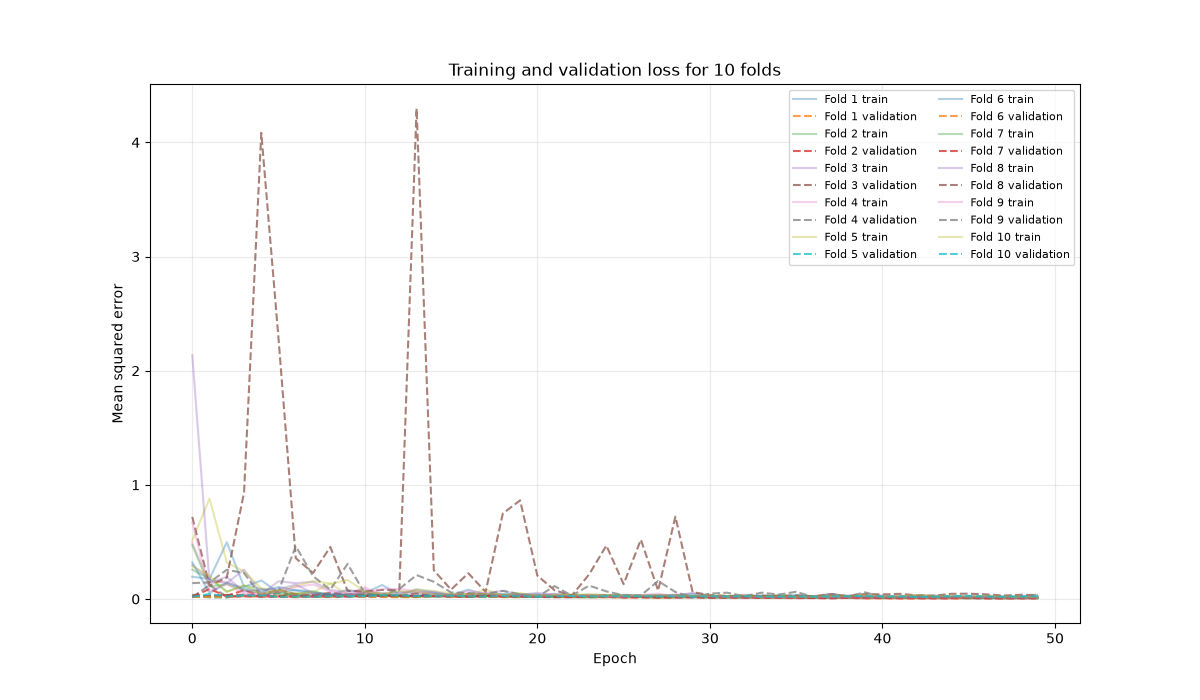

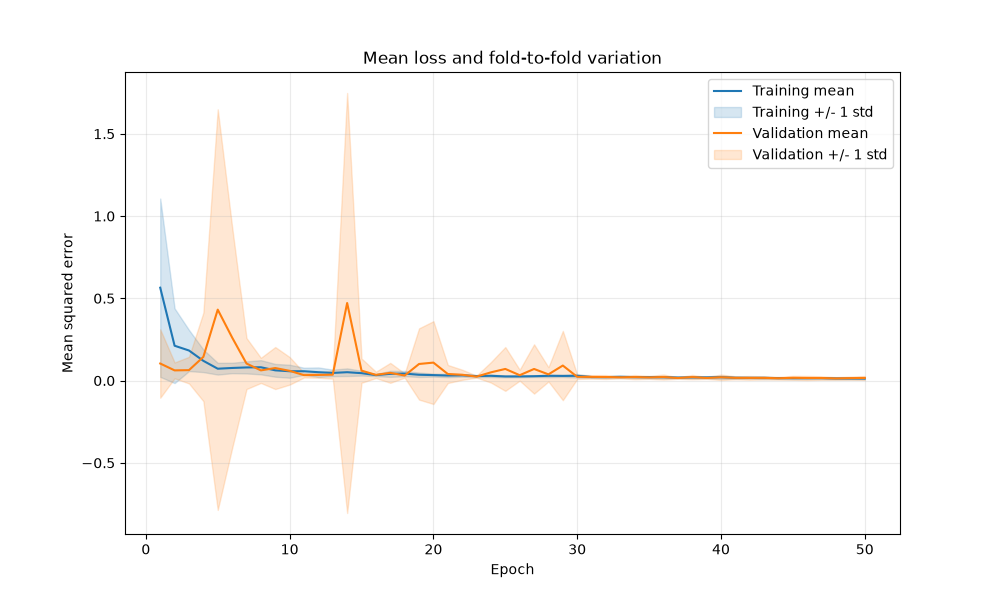

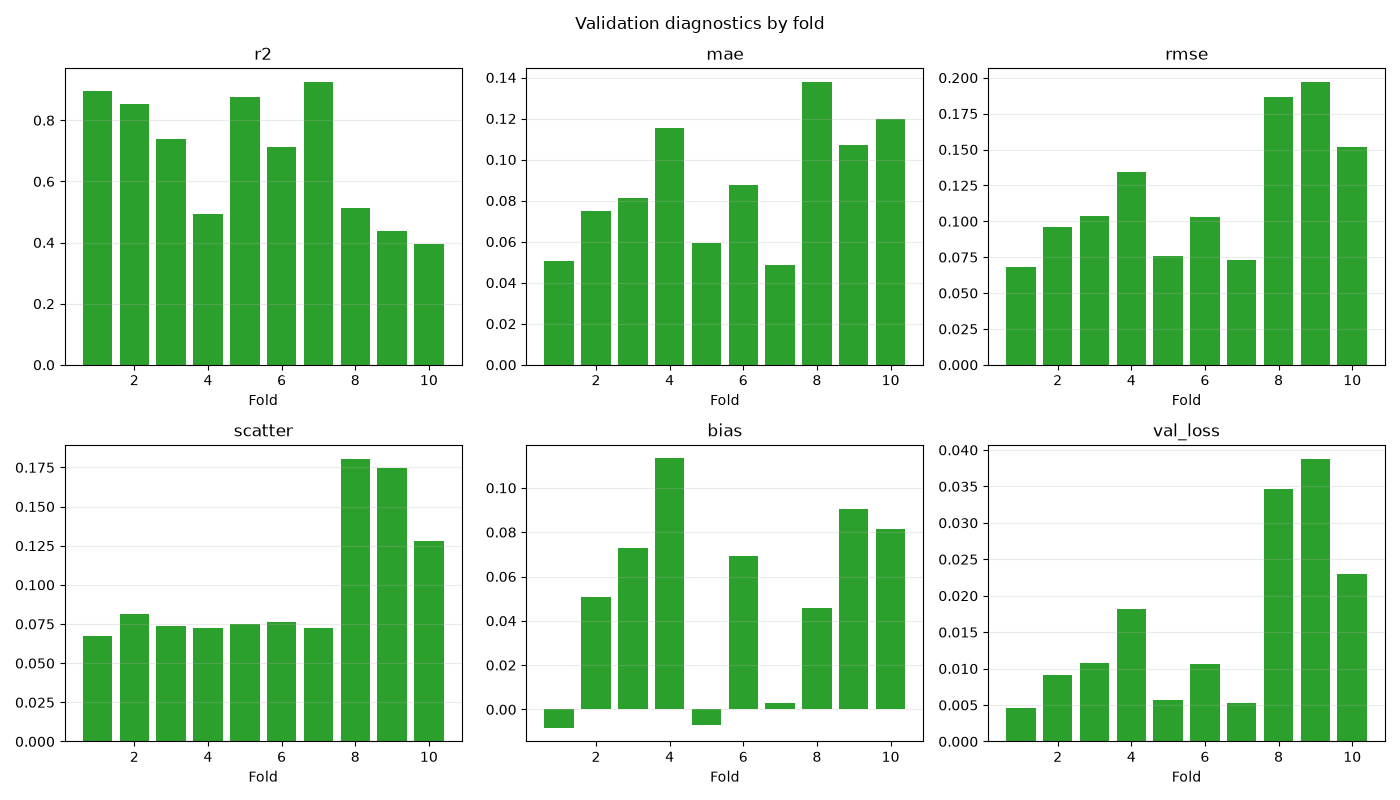

Fold metric summary:


,r2,mae,rmse,scatter,bias,val_loss
mean,0.683967,0.088263,0.118834,0.100244,0.051197,0.016079
std,0.205621,0.030904,0.046639,0.044289,0.042736,0.012364
min,0.395661,0.048568,0.067915,0.067396,-0.008386,0.004612
max,0.924914,0.137749,0.196946,0.180502,0.113431,0.038788


In [37]:
# Plot training and validation loss for every fold.
plt.figure(figsize=(12, 7))
for fold, history in enumerate(histories_no_rot, start=1):
    plt.plot(history.history['loss'], alpha=0.35, label=f'Fold {fold} train')
    plt.plot(history.history['val_loss'], alpha=0.75, linestyle='--', label=f'Fold {fold} validation')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Training and validation loss for 10 folds')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.show()

# Plot mean loss and one-standard-deviation spread across folds.
train_loss = np.array([history.history['loss'] for history in histories_no_rot])
val_loss = np.array([history.history['val_loss'] for history in histories_no_rot])
epoch_axis = np.arange(1, train_loss.shape[1] + 1)

plt.figure(figsize=(10, 6))
for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    plt.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    plt.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss,
                     color=color, alpha=0.18, label=f'{label} +/- 1 std')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Mean loss and fold-to-fold variation')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Compare final validation metrics across folds.
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_no_rot['fold'], cv_no_rot[metric], color='C2')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
plt.suptitle('Validation diagnostics by fold')
plt.tight_layout()
plt.show()

print('Fold metric summary:')
display(cv_no_rot[metrics].agg(['mean', 'std', 'min', 'max']))

In [38]:
cv_with_rot, histories_with_rot = run_cv(with_rotation=True)
print(cv_with_rot)
print('\n10-fold CV summary:')
print(cv_with_rot[['r2', 'mae', 'rmse', 'scatter', 'bias']].agg(['mean', 'std']))

# Run the augmented comparison when needed:
# cv_rot, histories_rot = run_cv(with_rotation=True)

   fold        r2       mae      rmse   scatter      bias  val_loss
0     1  0.465934  0.129395  0.153756  0.095615  0.120410  0.023641
1     2  0.303246  0.187114  0.207941  0.093669  0.185649  0.043240
2     3 -0.540893  0.226971  0.251902  0.109263  0.226971  0.063454
3     4 -0.865318  0.239588  0.258182  0.096206  0.239588  0.066658
4     5  0.646458  0.102031  0.127274  0.080949  0.098214  0.016199
5     6  0.606059  0.090993  0.120412  0.120349  0.003911  0.014499
6     7  0.375901  0.169364  0.209711  0.156601  0.139481  0.043979
7     8 -1.471941  0.213388  0.420298  0.420255 -0.005991  0.176650
8     9  0.005317  0.217746  0.262053  0.153967  0.212052  0.068672
9    10  0.597297  0.099438  0.123859  0.097075  0.076925  0.015341

10-fold CV summary:
            r2       mae      rmse   scatter      bias
mean  0.012206  0.167603  0.213539  0.142395  0.129721
std   0.730207  0.057712  0.092102  0.100913  0.087966


## Save models, outputs, and plot scripts

The following cells save the trained models, fold-level metrics, training histories, diagnostic plots, and a standalone Python plotting script. The export directory is created next to this notebook.

In [ ]:
from pathlib import Path
import json

output_dir = Path('cluster_mass_outputs_batchsize_32')
output_dir.mkdir(exist_ok=True)

# Save the most recently trained models when they exist in the notebook namespace.
models_to_save = {
    'baseline_model.keras': globals().get('model'),
    'test_model.keras': globals().get('test_model')
}
for filename, trained_model in models_to_save.items():
    if trained_model is not None:
        trained_model.save(output_dir / filename)
        print(f'Saved {filename}')

# Save fold-level result tables and compact training histories.
result_tables = {
    'cv_no_rotation.csv': cv_no_rot,
    'cv_with_rotation.csv': cv_with_rot
}
for filename, result_table in result_tables.items():
    result_table.to_csv(output_dir / filename, index=False)

history_data = {}
for prefix, histories in [
    ('no_rotation', histories_no_rot),
    ('with_rotation', histories_with_rot)
]:
    history_data[f'{prefix}_train_loss'] = np.asarray(
        [history.history['loss'] for history in histories]
    )
    history_data[f'{prefix}_val_loss'] = np.asarray(
        [history.history['val_loss'] for history in histories]
    )
np.savez(output_dir / 'training_histories.npz', **history_data)

metadata = {
    'n_folds': int(n_folds),
    'epochs': int(epochs),
    'batch_size': int(batch_size),
    'fold_seed': 42,
    'notes': 'Cluster-level folds; no_rotation and with_rotation use identical folds.'
}
(output_dir / 'run_metadata.json').write_text(json.dumps(metadata, indent=2))
print(f'Saved metrics, histories, and metadata to {output_dir.resolve()}')

Saved baseline_model.keras
Saved test_model.keras
Saved metrics, histories, and metadata to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_mass_outputs


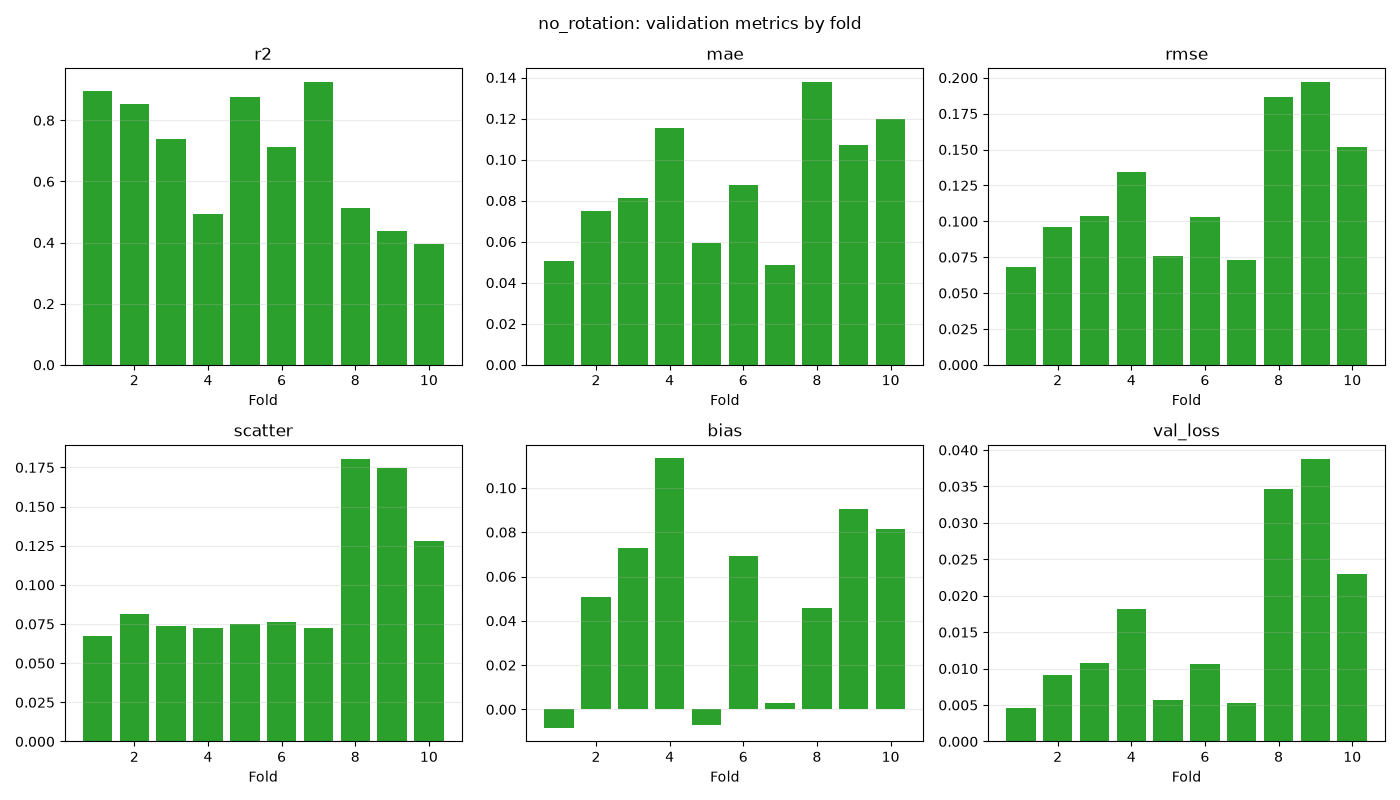

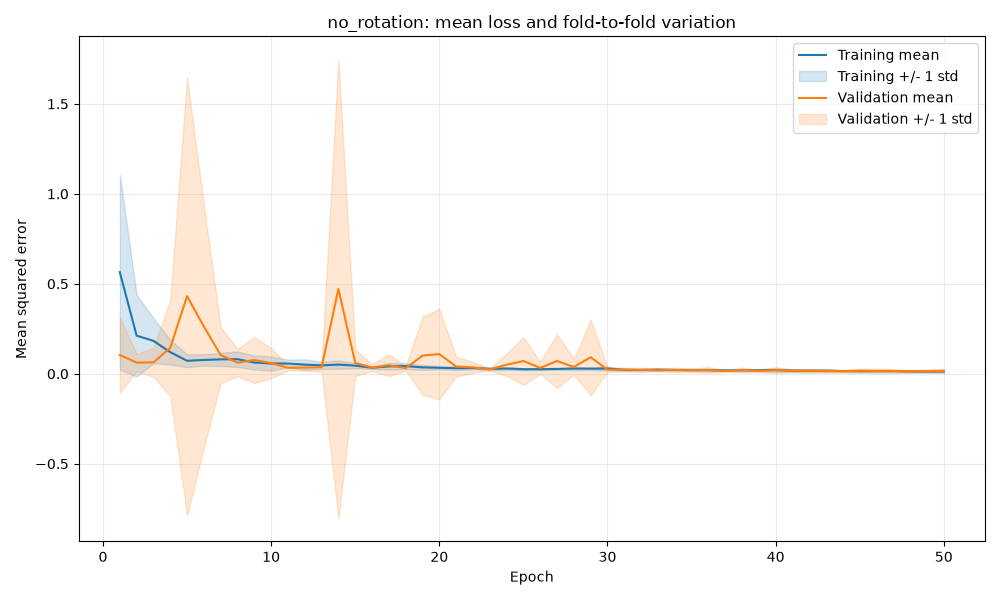

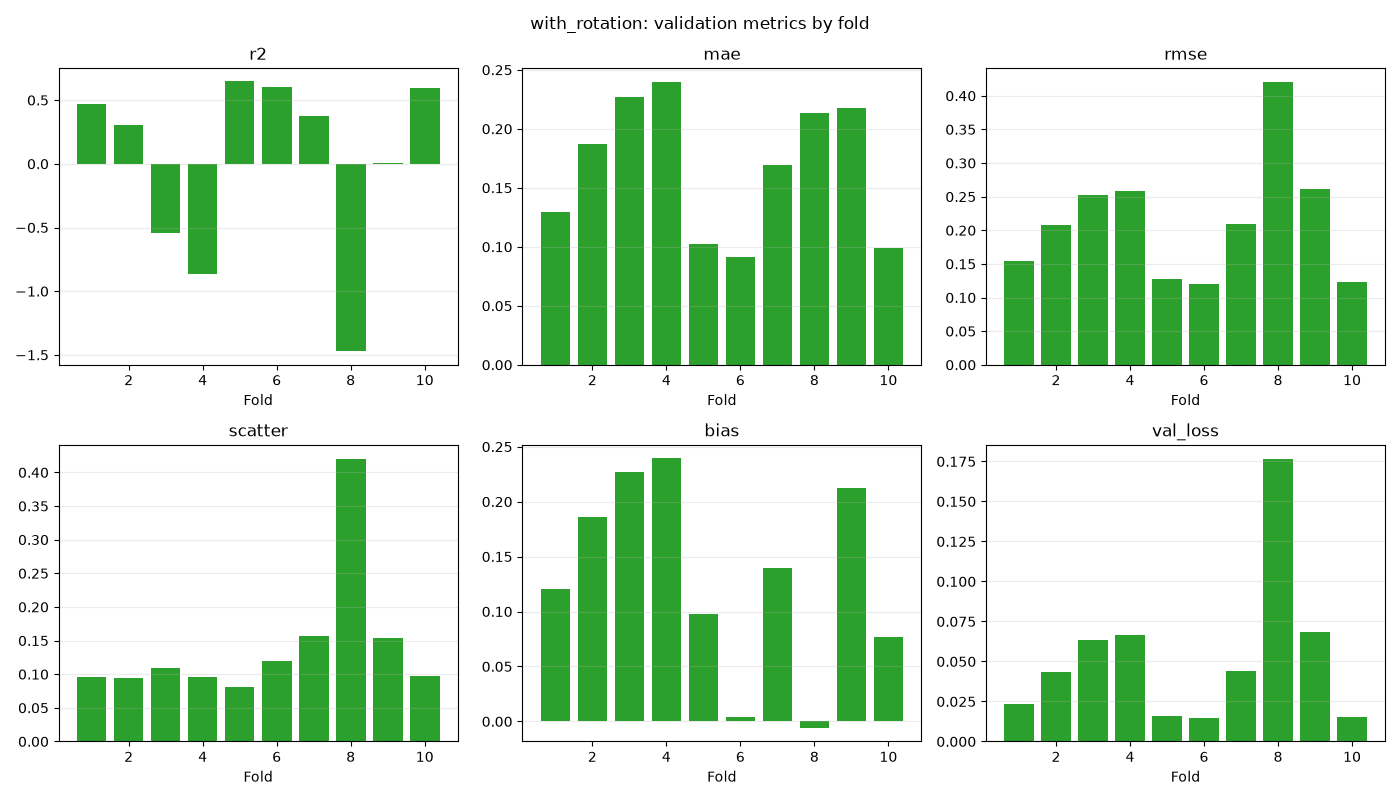

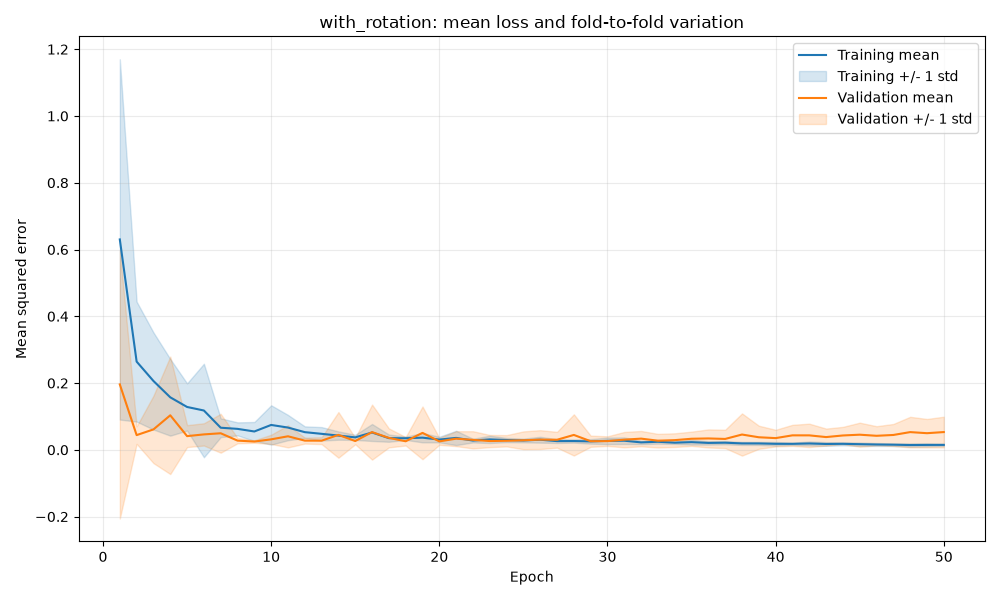

Saved four PNG plots to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_mass_outputs


In [40]:
def save_cv_plots(result_table, histories, prefix):
    metrics_to_plot = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for axis, metric in zip(axes.flat, metrics_to_plot):
        axis.bar(result_table['fold'], result_table[metric], color='C2')
        axis.set_title(metric)
        axis.set_xlabel('Fold')
        axis.grid(axis='y', alpha=0.25)
    fig.suptitle(f'{prefix}: validation metrics by fold')
    fig.tight_layout()
    fig.savefig(output_dir / f'{prefix}_metrics_by_fold.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    train_loss = np.asarray([history.history['loss'] for history in histories])
    val_loss = np.asarray([history.history['val_loss'] for history in histories])
    epoch_axis = np.arange(1, train_loss.shape[1] + 1)
    fig, axis = plt.subplots(figsize=(10, 6))
    for losses, label, color in [
        (train_loss, 'Training', 'C0'),
        (val_loss, 'Validation', 'C1')
    ]:
        mean_loss = losses.mean(axis=0)
        std_loss = losses.std(axis=0)
        axis.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
        axis.fill_between(
            epoch_axis,
            mean_loss - std_loss,
            mean_loss + std_loss,
            color=color,
            alpha=0.18,
            label=f'{label} +/- 1 std'
        )
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Mean squared error')
    axis.set_title(f'{prefix}: mean loss and fold-to-fold variation')
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f'{prefix}_loss_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

save_cv_plots(cv_no_rot, histories_no_rot, 'no_rotation')
save_cv_plots(cv_with_rot, histories_with_rot, 'with_rotation')
print('Saved four PNG plots to', output_dir.resolve())

In [41]:
plot_script = r'''from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(__file__).resolve().parent


def save_cv_plots(result_table, histories, prefix):
    metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for axis, metric in zip(axes.flat, metrics):
        axis.bar(result_table['fold'], result_table[metric], color='C2')
        axis.set_title(metric)
        axis.set_xlabel('Fold')
        axis.grid(axis='y', alpha=0.25)
    fig.suptitle(f'{prefix}: validation metrics by fold')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{prefix}_metrics_by_fold.png', dpi=200, bbox_inches='tight')
    plt.close(fig)

    train_loss = histories[f'{prefix}_train_loss']
    val_loss = histories[f'{prefix}_val_loss']
    epoch_axis = np.arange(1, train_loss.shape[1] + 1)
    fig, axis = plt.subplots(figsize=(10, 6))
    for losses, label, color in [
        (train_loss, 'Training', 'C0'),
        (val_loss, 'Validation', 'C1')
    ]:
        mean_loss = losses.mean(axis=0)
        std_loss = losses.std(axis=0)
        axis.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
        axis.fill_between(
            epoch_axis,
            mean_loss - std_loss,
            mean_loss + std_loss,
            color=color,
            alpha=0.18,
            label=f'{label} +/- 1 std'
        )
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Mean squared error')
    axis.set_title(f'{prefix}: mean loss and fold-to-fold variation')
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{prefix}_loss_curves.png', dpi=200, bbox_inches='tight')
    plt.close(fig)


for prefix in ['no_rotation', 'with_rotation']:
    results = pd.read_csv(OUTPUT_DIR / f'cv_{prefix}.csv')
    save_cv_plots(results, np.load(OUTPUT_DIR / 'training_histories.npz'), prefix)
print(f'Plots regenerated in {OUTPUT_DIR}')
'''
(output_dir / 'plot_cv_outputs.py').write_text(plot_script)
print(f'Saved standalone plot script to {(output_dir / "plot_cv_outputs.py").resolve()}')

Saved standalone plot script to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_mass_outputs/plot_cv_outputs.py
